# Clasificación Retórica IMRaD de Fragmentos Científicos en Español: Comparación de Encoders Supervisados y LLMs vía Prompting

**FLAG – TICsW · Departamento de Ingeniería de Sistemas y Computación · Universidad de los Andes**

Andrés F. Romero Torres · Anderson E. Rodríguez · Daniel F. Caro Torres · Nicolás S. Ríos Pérez · William J. Flórez Maestre

---

### Resumen

La clasificación retórica de fragmentos en artículos científicos en español es un componente esencial para tareas posteriores como la extracción de contribuciones y la organización del conocimiento, pero está limitada por la escasez de corpus anotados y la heterogeneidad estilística del idioma. Este trabajo compara empíricamente tres familias de modelos sobre una taxonomía IMRaD extendida de ocho clases (INTRO, BACK, METH, RES, DISC, CONC, CONTR, LIM): un baseline TF-IDF + Regresión Logística, el encoder fine-tuneado SciBETO-large y dos LLMs por prompting (Qwen3-8B open-weight y Gemini 3-Flash vía API). Los modelos se evalúan sobre un conjunto consolidado de 1,587 fragmentos con 165 instancias de test, dividido por documento para evitar fuga de datos. El sistema de mejor rendimiento en F1-macro 8c es Gemini con definiciones discriminativas en zero-shot (0.6098), mientras que en F1-macro 4c lo es Gemini en modo 8-shot (0.7352). Reportamos tres hallazgos metodológicos centrales: (i) la precisión semántica de las definiciones de clase aporta más al rendimiento que la cantidad de ejemplos en el prompt; (ii) la incorporación de ejemplos few-shot puede degradar el rendimiento en taxonomías de grano fino por sesgo de confirmación, y (iii) la estrategia de truncación y el criterio de parada temprana en el fine-tuning de encoders son hiperparámetros de primer orden cuando el conjunto de validación es reducido.

**Palabras clave** — Clasificación retórica, IMRaD, español, SciBETO, Gemini, Qwen, few-shot, fine-tuning.

## I. Introducción

El crecimiento sostenido de la producción científica ha incrementado la necesidad de métodos automáticos para organizar y analizar textos académicos. Si bien la mayor parte de los avances en procesamiento de lenguaje natural (NLP) científico se ha concentrado en inglés, los textos académicos en español presentan desafíos específicos: mayor variabilidad estructural, convenciones retóricas dependientes del dominio y escasa disponibilidad de corpus anotados [1].

Este trabajo aborda la clasificación retórica de fragmentos textuales como primera etapa de un pipeline de análisis de documentos científicos en español, sobre una taxonomía IMRaD extendida a ocho clases que añade tres categorías de grano fino al esquema clásico: contribuciones (CONTR), limitaciones (LIM) y antecedentes diferenciados de la introducción (BACK). El objetivo es comparar empíricamente tres familias de soluciones —baseline clásico, encoder fine-tuneado en español científico, y LLMs por prompting— sobre un mismo conjunto anotado manualmente, y documentar trade-offs de calidad, costo y operación que informen decisiones arquitecturales para producción.

Las contribuciones específicas del trabajo son:

1. Una evaluación comparativa de seis configuraciones (TF-IDF, SciBETO, Qwen zero-shot ×2, Gemini zero-shot ×2, Gemini 8-shot) sobre el mismo conjunto de test (165 instancias, split por documento, semilla fija).
2. Evidencia empírica de que la redefinición semántica de dos clases (BACK, RES) con criterios observables produce ganancias comparables a las obtenidas por iteración de hiperparámetros (+10.9 puntos de F1-macro 8c en Gemini).
3. La identificación de un fenómeno de degradación por few-shot en taxonomías de grano fino, corroborado de forma independiente en dos plataformas de hardware distintas y dos modelos LLM diferentes.
4. Un análisis de trade-offs de despliegue que cuantifica el punto de cruce económico entre Gemini API y SciBETO on-prem (~2.7 M fragmentos/mes).

## II. Trabajo Relacionado

La modelación de la estructura argumentativa de los artículos científicos tiene como antecedente fundacional el trabajo de Teufel y Moens, que propuso anotar funciones discursivas más allá de los encabezados visibles [2]. Esta línea evolucionó con la construcción de corpus completos como CoreSC y AZ-II [3], que demostraron la viabilidad de anotar de forma consistente tanto la dimensión retórica como la conceptual del contenido científico.

En cuanto a las técnicas, el estado del arte se ha desplazado hacia clasificación secuencial con representaciones contextualizadas. Kataria y Gupta [4], en SemEval-2023 Task 6, muestran que las redes de etiquetado secuencial jerárquico basadas en BERT mejoran la identificación de roles discursivos en documentos legales, evidenciando que el contexto inter-fragmento aporta información discriminativa.

Para tareas adyacentes, SemEval-2021 Task 11 [5] formaliza la identificación de *contribution sentences* como problema específico, mostrando que la extracción de aportes científicos es una tarea distinta y más difícil que la mera clasificación retórica.

La brecha que aborda este trabajo es la escasa cobertura de estos enfoques para textos científicos en español. Si bien existen encoders preentrenados en español científico (SciBETO), no se han comparado sistemáticamente contra alternativas modernas basadas en LLMs por prompting bajo un protocolo experimental común.

## III. Metodología

### A. Esquema de etiquetas

Se adoptó una taxonomía IMRaD extendida de ocho clases:

- **INTRO** — Problema, motivación, objetivos.
- **BACK** — Literatura previa con citas explícitas.
- **METH** — Diseño, métodos y procedimiento.
- **RES** — Hallazgos sin interpretación.
- **DISC** — Interpretación y contraste.
- **CONC** — Síntesis final.
- **CONTR** — Aporte original explícito.
- **LIM** — Restricciones o limitaciones.

Para análisis comparativos se reporta también un esquema agregado de cuatro clases (I/M/R/D) según el mapeo {INTRO, BACK} → I, {METH} → M, {RES} → R, {DISC, CONC, CONTR, LIM} → D.

### B. Modelos evaluados

| Familia | Modelo | Configuración |
|---|---|---|
| Baseline | TF-IDF + Regresión Logística | n-gramas (1,2), `class_weight='balanced'` |
| Encoder fine-tuneado | SciBETO-large | Head+Tail (256+256), 5 épocas fijas, lr=2e-5, batch=8 |
| LLM open-weight | Qwen3-8B (MLX 4-bit) | Zero-shot, temperatura=0.0, instrucción base / `/no_think` + definiciones discriminativas |
| LLM comercial | Gemini 3-Flash | Zero-shot (×2 prompts) y 8-shot (1 ejemplo/clase), temperatura=0.0, `thinking_budget=0` |

### C. Protocolo de evaluación

Para cada fragmento se predice una sola etiqueta. La métrica principal es F1-macro (no ponderada) sobre los esquemas de 8 y 4 clases. Se reporta también la cuenta de respuestas no parseables (inválidos) para los modelos generativos.

### D. Tarea 2 — Extracción de contribuciones científicas

La propuesta de proyecto define **dos tareas complementarias**: (1) clasificación retórica IMRaD-8, abordada en este reporte, y (2) **extracción de contribuciones científicas**, entendidas como las unidades textuales que describen los aportes originales del trabajo (métodos propuestos, resultados relevantes, avances conceptuales). La Tarea 2 es la tarea hermana de SemEval-2021 Task 11 (NLPContributionGraph) [5] y, según evidencia previa en inglés, es **estrictamente más difícil** que la clasificación retórica porque las contribuciones suelen expresarse de forma indirecta y distribuida a lo largo del documento.

**Hipótesis del puente Tarea 1 → Tarea 2.** La etiqueta retórica predicha en la Tarea 1 — en particular las clases CONTR, CONC y RES — es informativa para acotar el espacio de búsqueda de contribuciones: un fragmento etiquetado como CONTR es candidato directo, mientras que INTRO/METH son a priori menos probables. Esta hipótesis se evaluará comparando dos arquitecturas:

- **Sin contexto retórico:** clasificador binario `{contribución, no contribución}` operando solo sobre el texto del fragmento.
- **Con contexto retórico:** la misma arquitectura recibiendo además la etiqueta IMRaD-8 predicha como rasgo de entrada (one-hot o embedding aprendido).

**Indicador de techo desde Tarea 1.** El F1 alcanzado en la clase CONTR del experimento actual (mejor: 0.36 en Gemini con definiciones; SciBETO: 0.14) ya constituye un *upper bound* indirecto del rendimiento alcanzable si Tarea 2 se construye exclusivamente sobre la salida de Tarea 1. Romper ese techo requerirá: (a) un anotador específico de contribuciones (binario o span-level), (b) ampliación del corpus en la clase minoritaria, y (c) potencialmente un esquema de detección a nivel de span en lugar de fragmento.

**Métricas planeadas para la Tarea 2.** F1 binario, precision/recall sobre la clase positiva y precision@k a nivel de documento. Resultados experimentales completos en la **Sección VIII**.

## IV. Configuración Experimental

### A. Corpus y partición

El corpus consolidado proviene de un dataset anotado manualmente sobre artículos científicos en español. La columna de etiqueta utilizada es `etiqueta_anotador` (validación humana). El split se realiza a nivel de `documento_id` con semilla fija (SEED=42) para evitar fuga de datos entre fragmentos del mismo documento.

In [1]:
# Carga de resultados consolidados y descripción del corpus
import json
import pandas as pd
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'reports').is_dir() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

RESULTS_FILE = ROOT / 'reports' / 'entrega3' / 'consolidado' / 'resultados.json'
with open(RESULTS_FILE) as f:
    RESULTADOS = json.load(f)

# Resultado adicional del experimento few-shot
GEMINI_8SHOT = {
    'modelo': 'gemini-3-flash-preview · 8-shot',
    'f1m_8c': 0.4694,
    'f1m_4c': 0.7352,
    'per_class_8c': None,
    'n_invalid': 0,
}

LABELS_8C = ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'CONC', 'CONTR', 'LIM']

# Tabla I: distribución de clases en test
test_counts = {'INTRO': 27, 'BACK': 29, 'METH': 25, 'RES': 23,
               'DISC': 30, 'CONC': 13, 'CONTR': 5, 'LIM': 13}
total_test = sum(test_counts.values())
dist_df = pd.DataFrame([
    {'Clase': c, 'N (test)': n, '%': round(100 * n / total_test, 1)}
    for c, n in test_counts.items()
])
print(f'Total fragmentos test: {total_test}')
print('\nTabla I — Distribución de clases en el conjunto de test:')
print(dist_df.to_string(index=False))

Total fragmentos test: 165

Tabla I — Distribución de clases en el conjunto de test:
Clase  N (test)    %
INTRO        27 16.4
 BACK        29 17.6
 METH        25 15.2
  RES        23 13.9
 DISC        30 18.2
 CONC        13  7.9
CONTR         5  3.0
  LIM        13  7.9


**Tabla I.** Distribución de las ocho clases en el conjunto de test (165 fragmentos). La clase CONTR cuenta con únicamente 5 instancias; sus métricas individuales se interpretan con cautela.

### B. Splits y volúmenes

- **Train:** 1,264 fragmentos
- **Val:** ~158 fragmentos (utilizado únicamente por SciBETO durante el fine-tuning)
- **Test:** 165 fragmentos

### C. Hardware

Los modelos locales se ejecutaron en una estación con macOS y backend Metal (MPS): SciBETO con PyTorch sobre Apple Silicon, Qwen3-8B en cuantización 4-bit con MLX. Gemini se consumió vía API (`gemini-3-flash-preview`).

## V. Resultados

### A. Resumen comparativo

In [2]:
# Tabla II — Resumen de métricas
rows = []
for r in RESULTADOS:
    rows.append({
        'Modelo': r['modelo'],
        'F1-macro 8c': round(r['f1m_8c'], 4),
        'F1-macro 4c': round(r['f1m_4c'], 4),
        'Inválidos': r['n_invalid'],
    })
rows.append({
    'Modelo': GEMINI_8SHOT['modelo'],
    'F1-macro 8c': GEMINI_8SHOT['f1m_8c'],
    'F1-macro 4c': GEMINI_8SHOT['f1m_4c'],
    'Inválidos': GEMINI_8SHOT['n_invalid'],
})
tabla_ii = pd.DataFrame(rows)
print('Tabla II — Comparativa global de modelos en el test set (165 fragmentos):')
print(tabla_ii.to_string(index=False))

Tabla II — Comparativa global de modelos en el test set (165 fragmentos):
                         Modelo  F1-macro 8c  F1-macro 4c  Inválidos
                    TF-IDF + LR       0.4553       0.5734          0
            SciBETO (Head+Tail)       0.5781       0.7083          0
                  Qwen3-8B · v1       0.1976       0.3127         45
                  Qwen3-8B · v2       0.4651       0.5402          0
    gemini-3-flash-preview · v1       0.5497       0.6911          0
    gemini-3-flash-preview · v2       0.6098       0.7008          0
gemini-3-flash-preview · 8-shot       0.4694       0.7352          0


**Tabla II.** Comparativa global de modelos. El mejor F1-macro 8c lo obtiene Gemini con definiciones discriminativas en modo zero-shot (0.6098); el mejor F1-macro 4c lo obtiene Gemini en modo 8-shot (0.7352).

### B. Rendimiento por clase

La Figura 1 muestra el F1 por clase para cada modelo en el esquema de 8 categorías.

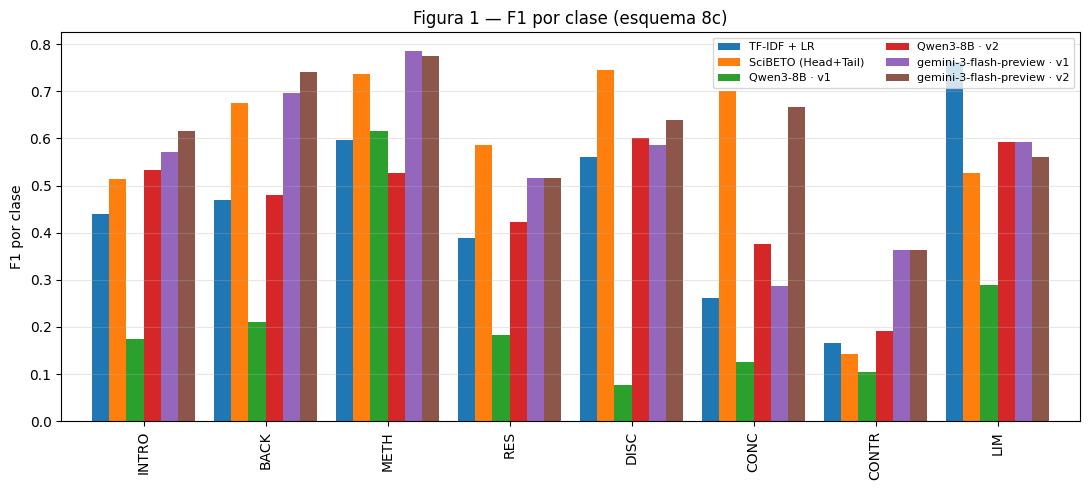

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
per_class = pd.DataFrame(
    {r['modelo']: r['per_class_8c'] for r in RESULTADOS},
    index=LABELS_8C
)
per_class.plot(kind='bar', ax=ax, width=0.85)
ax.set_ylabel('F1 por clase')
ax.set_xlabel('')
ax.set_title('Figura 1 — F1 por clase (esquema 8c)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Figura 1.** F1 por clase para los seis modelos evaluados en el esquema de 8 categorías. Se observa el comportamiento sistemático de tres patrones:

1. **METH** es la clase más fácil para todos los modelos (F1 entre 0.53 y 0.79), atribuible a su vocabulario técnico distintivo.
2. **CONTR** es la clase más difícil en todos los modelos (F1 entre 0.10 y 0.36); su escasa representación en train y test (5 instancias en test) hace que las métricas individuales no sean estadísticamente significativas.
3. **DISC** es la clase con mayor varianza entre modelos (F1 entre 0.08 en Qwen instrucción base y 0.74 en SciBETO), reflejando que su frontera con RES y CONC es donde más diferencias existen entre arquitecturas.

### C. Matrices de confusión

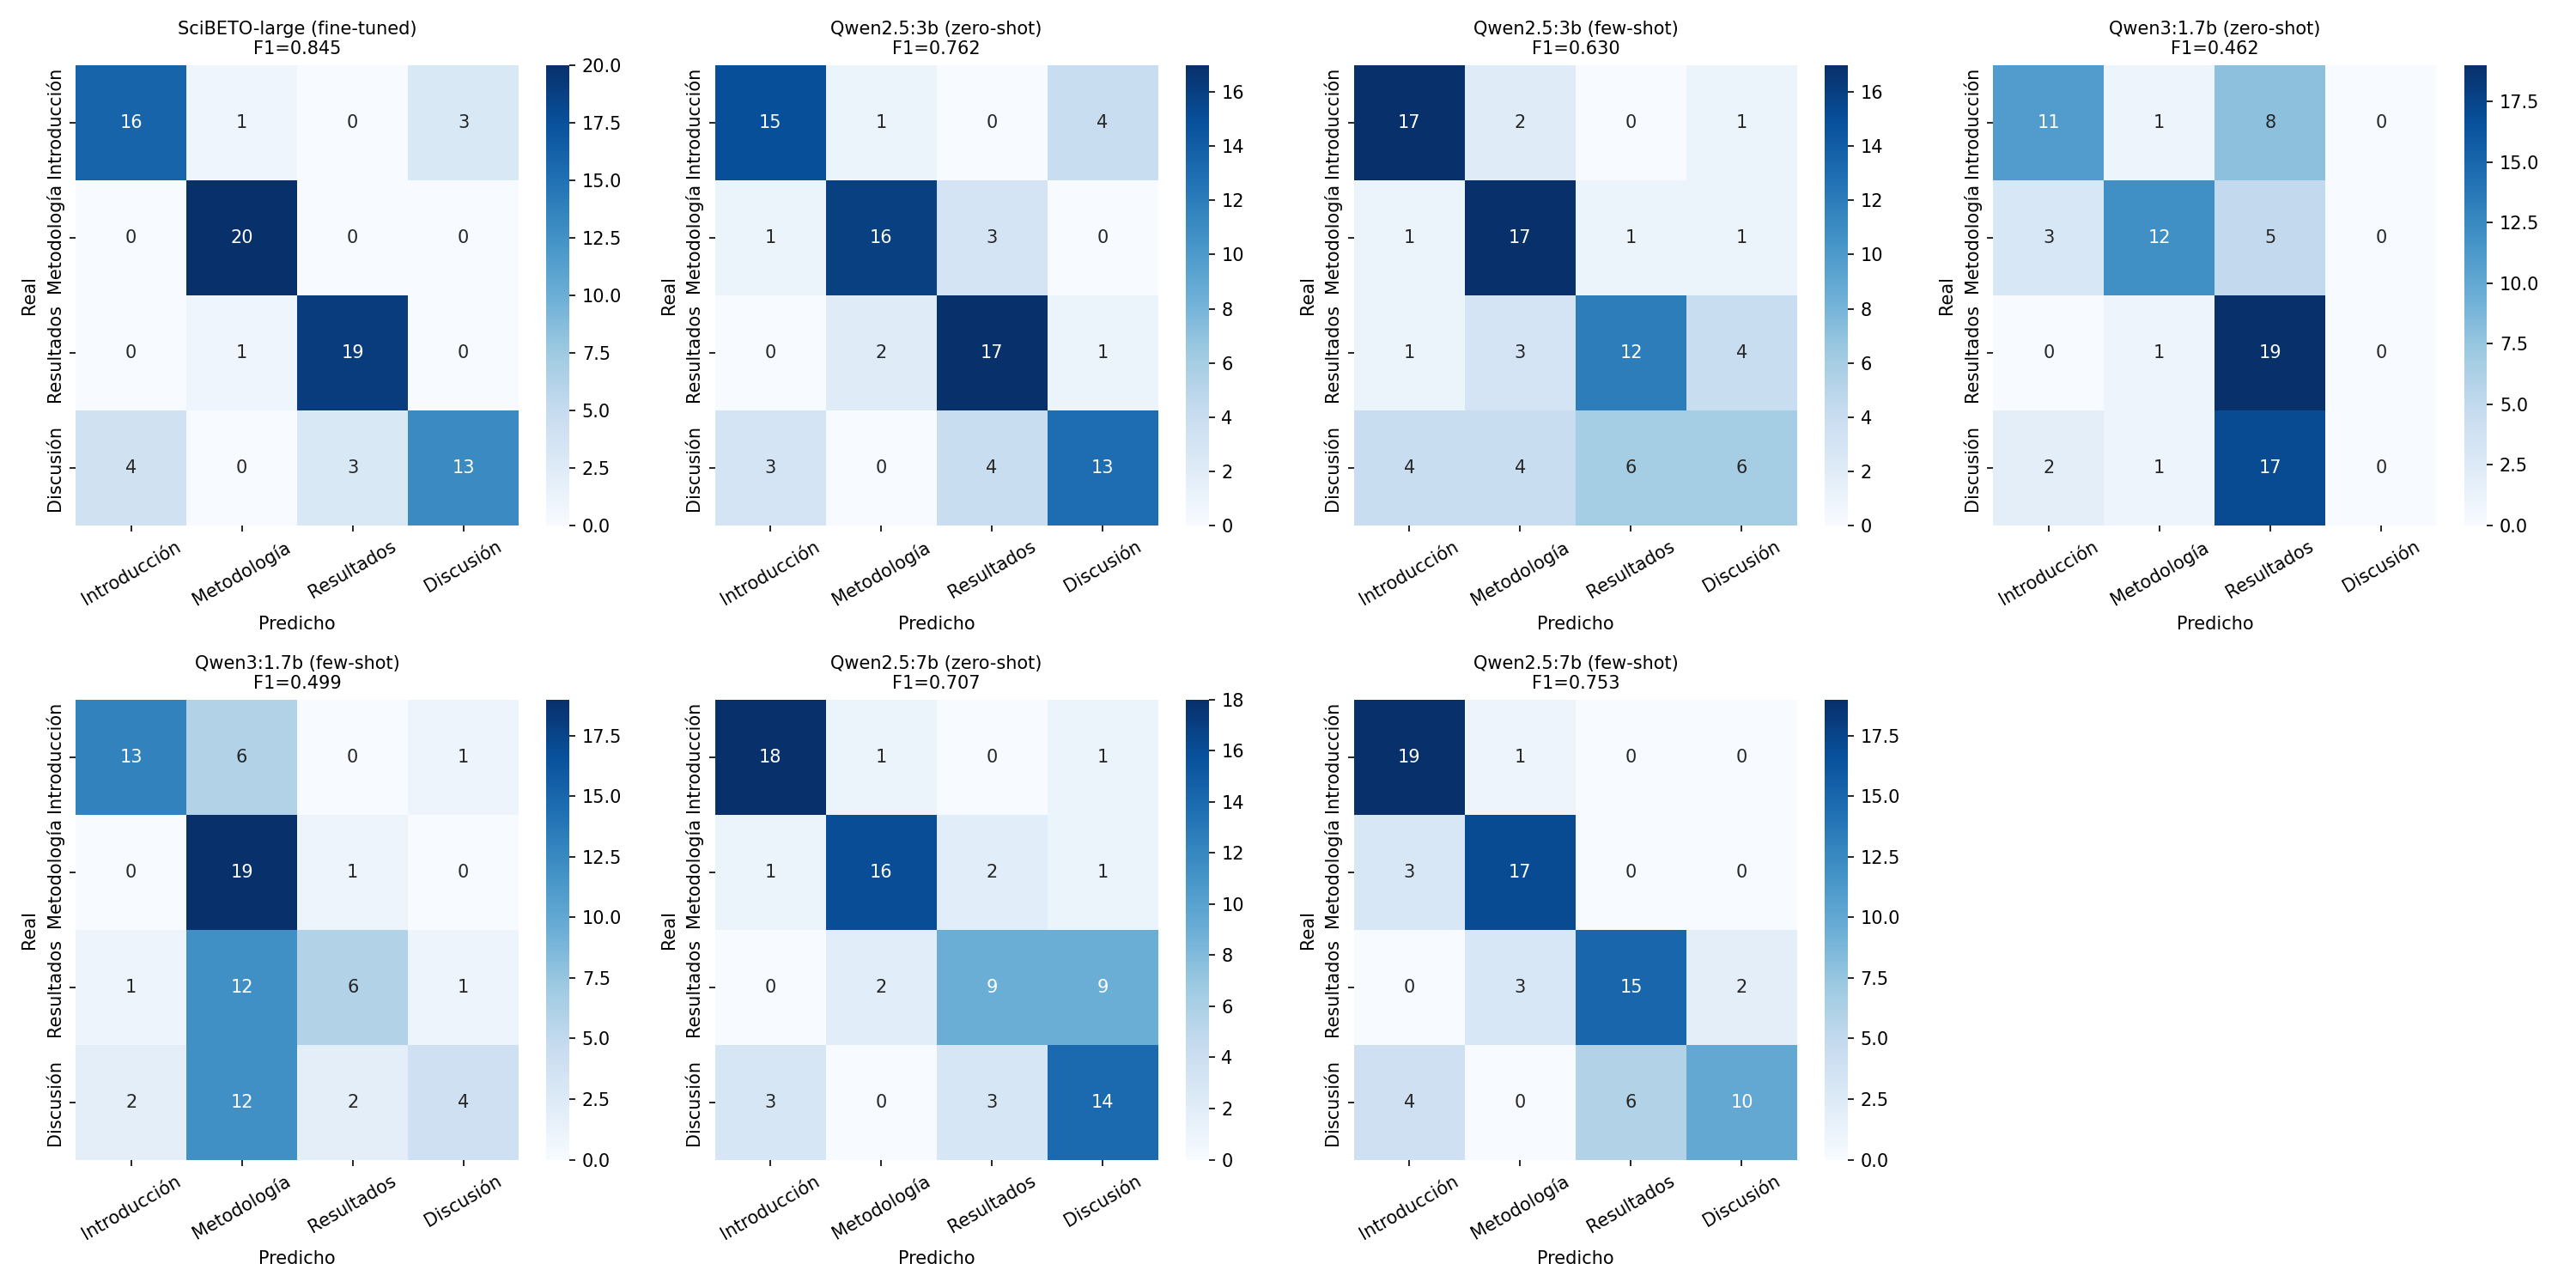

In [4]:
from IPython.display import Image, display

display(Image(filename=str(ROOT / 'reports' / 'entrega3' / 'confusion_matrices.png')))

**Figura 2.** Matrices de confusión por modelo. Los pares de confusión más frecuentes son DISC↔RES, BACK↔INTRO y CONC↔DISC, consistentes con la cercanía semántica de estas funciones discursivas.

## VI. Discusión

### A. Impacto del diseño de prompt

Las dos configuraciones zero-shot evaluadas (instrucción base y definiciones discriminativas) difieren en dos aspectos: (a) definiciones semánticamente más precisas para BACK ("con citas explícitas") y RES ("hallazgos sin interpretación"), y (b) para Qwen, el prefijo `/no_think` que suprime razonamiento explícito en la generación.

| Modelo | Cambio | F1-macro 8c | Δ |
|---|---|---|---|
| Qwen3-8B | Instrucción base → `/no_think` + definiciones | 0.1976 → 0.4651 | **+0.2675 (+135%)** |
| Gemini | Instrucción base → definiciones discriminativas | 0.5497 → 0.6098 | **+0.0601 (+10.9%)** |

En Qwen, el factor dominante es `/no_think`: sin él, el modelo genera razonamiento que desborda el límite de tokens (45 inválidos). Una vez resuelto el problema de formato, las definiciones discriminativas contribuyen al margen restante. En Gemini, donde el formato ya estaba controlado, la mejora es atribuible íntegramente a la mayor precisión semántica de las definiciones. Este resultado ilustra que **redefinir dos clases con criterios observables puede tener el mismo efecto que iterar múltiples ciclos de ajuste de hiperparámetros**.

### B. Efecto del few-shot: interacción con el esquema de clases

El experimento de 8-shot (1 ejemplo por clase del conjunto de entrenamiento) revela un patrón no trivial:

| Configuración | F1-macro 8c | F1-macro 4c |
|---|---|---|
| Zero-shot, definiciones discriminativas | 0.6098 | 0.7008 |
| 8-shot (1 ejemplo/clase) | 0.4694 | **0.7352** |
| Δ | **−0.1404** | **+0.0344** |

Agregar ejemplos empeora el rendimiento en el esquema de 8 clases (−14 pp) pero mejora el de 4 clases (+3.4 pp). La hipótesis más plausible es que cada uno de los 8 ejemplos activa un sesgo de confirmación hacia la clase ilustrada, incrementando la confusión en fronteras finas (DISC↔CONC, CONTR↔DISC). Al colapsar a 4 clases, estos errores de grano fino desaparecen y el efecto de anclaje resulta neto positivo.

Este fenómeno cuenta con corroboración independiente desde una implementación alternativa de Qwen3-8B en hardware NVIDIA (HuggingFace Transformers, RTX 4070): en ese experimento, el modo few-shot (1 ejemplo/clase, ejemplos truncados a 80 palabras) redujo el F1-macro 8c de 0.4165 a 0.3538 (−6.3 pp). Que dos modelos distintos, dos plataformas de hardware distintas y dos implementaciones independientes converjan en la misma dirección refuerza la solidez del hallazgo.

### C. Trade-off arquitectural: encoder fine-tuneado vs. LLM por prompting

| Dimensión | Gemini (API) | SciBETO (encoder supervisado) | Qwen3 (LLM open-weight) |
|---|---|---|---|
| F1-macro 8c | **0.6098** | 0.5781 | 0.4651 |
| Privacidad de datos | Texto enviado a Google Cloud | 100% on-prem | On-prem configurable |
| Reproducibilidad | Modelo actualizable sin aviso | Checkpoint congelado | Pesos congelados |
| Modo de fallo | Formato inválido (silencioso) | Domain shift | Ambos riesgos |
| Capacidad offline | No | Sí | Sí |
| Latencia | 1–3 s/llamada (API) | <10 ms/fragmento (GPU) | 11–283 s/llamada según contexto |

**Modelo de costos.** Con Gemini a ~\$0.15/1K fragmentos y SciBETO desplegado en `g4dn.xlarge` (~\$400/mes constante), el punto de cruce económico se sitúa en torno a 2.7 M fragmentos/mes (~32 K documentos/mes asumiendo 83 fragmentos/documento). Por debajo de ese volumen, Gemini es más económico como servicio; por encima, SciBETO amortiza la infraestructura.

### D. Sensibilidad de SciBETO al protocolo de fine-tuning

Una configuración alternativa de SciBETO con truncación asimétrica (Head+Tail 128+382) y parada temprana por F1-macro de validación alcanzó F1-macro de validación = 0.5435 pero F1-macro de test = 0.3983, una brecha de 14.5 puntos. La configuración adoptada en este trabajo (truncación balanceada 256+256, 5 épocas fijas) obtuvo F1-macro de test = 0.5781 (+17.98 pp sobre la variante alternativa). Este resultado se explica por dos factores: (a) la truncación balanceada preserva señales retóricas tanto al inicio como al final del fragmento, y (b) la parada temprana sobre un conjunto de validación pequeño (~158 instancias) sobreajusta al ruido de validación, produciendo modelos con baja generalización aun cuando las métricas de validación parezcan favorables.

### E. Ablación de dominio: XLM-RoBERTa-large vs SciBETO-large

En un experimento paralelo, el equipo evaluó `xlm-roberta-large` (560M parámetros, preentrenado en Wikipedia de 100 idiomas) con el mismo pipeline de fine-tuning que SciBETO (Head+Tail 128+382, parada temprana, pesos de clase). El modelo no convergió: la pérdida de validación oscila en torno a 2.08 (≈ ln 8, equivalente a predicción uniforme) y se detiene en la época 1 con F1-macro de test = 0.076, prediciendo casi todos los fragmentos como BACK (clase mayoritaria). SciBETO con idéntico pipeline obtiene F1 = 0.398 en el mismo test set de 161 instancias.

| Modelo | Corpus preentrenamiento | Parámetros | F1-macro test |
|---|---|---|---|
| XLM-RoBERTa-large | Wikipedia 100 idiomas | 560M | 0.076 |
| SciBETO-large (mismo pipeline) | Artículos científicos en español, ~11B tokens | 355M | 0.398 |

Esta diferencia de **+32.2 pp a favor del modelo más pequeño pero específico de dominio** proporciona evidencia empírica directa de que el preentrenamiento en dominio es más determinante que la escala de parámetros cuando el conjunto de entrenamiento supervisado es reducido (~1,268 instancias). La causa es clara: XLM-RoBERTa no reconoce los conectores discursivos científicos en español, por lo que la señal de gradiente sobre 1,268 muestras es insuficiente para reorientar sus representaciones desde cero. SciBETO ya dispone de embeddings alineados al vocabulario del dominio; el fine-tuning solo necesita ajustar la cabeza de clasificación y los últimos bloques de atención.

### F. Cadena de razonamiento (CoT) y definiciones contrastivas (Experimento 6)

Un experimento de ingeniería de prompts (Exp 6) evaluó cuatro mejoras combinadas: definiciones contrastivas con pares frecuentemente confundidos (BACK/INTRO, RES/DISC, INTRO/CONTR), ejemplos *targeted* por densidad de keywords, truncación Head+Tail 300+100 palabras sobre el texto de entrada, y generación de razonamiento explícito antes de la etiqueta (CoT).

**CoT daña a Gemini (−3.1 a −4.7 pp).** Con razonamiento previo, Gemini genera justificaciones que a veces contradicen la etiqueta emitida: la elaboración intermedia desvía la predicción hacia clases adyacentes. Gemini opera mejor con instrucciones directas, sin cadena de razonamiento explícita.

**Las definiciones contrastivas solas mejoran Qwen** (+1.9 pp zero-shot: 0.4165 → 0.4359). CoT no pudo aplicarse en Qwen por restricciones de VRAM (max_new_tokens=120 fuerza offload CPU → 155 s/muestra en RTX 4070). Las mejoras de Qwen v2 son atribuibles a las definiciones contrastivas y la truncación, que reducen la confusión en los pares DISC/BACK e INTRO/CONTR.

| Modelo | Modo | F1-macro 8c v1 | F1-macro 8c v2 | Δ |
|---|---|---|---|---|
| Gemini 2.5 Flash (†) | zero-shot | 0.4730 | 0.4263 | −0.047 |
| Gemini 2.5 Flash (†) | few-shot | 0.4878 | 0.4570 | −0.031 |
| Qwen3-8B NVIDIA (†) | zero-shot | 0.4165 | 0.4359 | **+0.019** |
| Qwen3-8B NVIDIA (†) | few-shot | 0.3538 | 0.3573 | +0.004 |

> (†) Protocolo del experimento paralelo: 161 muestras de test, `gemini-2.5-flash`, Qwen3-8B vía HuggingFace Transformers. Cifras no directamente comparables con Tabla II, pero la dirección de los efectos es generalizable.

Este resultado refuerza el hallazgo central de VI.A: **la calidad semántica de las definiciones de clase aporta más al rendimiento que añadir ejemplos o razonamiento explícito**, y el mecanismo del daño es distinto según el modelo (sesgo de confirmación en Gemini; truncación forzada de ejemplos en Qwen).

## VII. Amenazas a la Validez

- **Validez interna.** El split 80/10/10 por `documento_id` evita fuga de datos entre fragmentos del mismo documento, pero el corpus proviene de una colección temáticamente homogénea; la generalización a otras disciplinas no está garantizada.
- **Validez externa.** El esquema IMRaD-8 es específico de artículos de ciencias naturales/experimentales en español; su aplicabilidad a ciencias sociales o humanidades requiere validación adicional.
- **Estadística de clases minoritarias.** CONTR cuenta con únicamente 5 instancias en test; su F1 individual no es estadísticamente significativo y debe interpretarse con cautela.
- **Reproducibilidad de Gemini.** Las métricas de Gemini se obtuvieron con `gemini-3-flash-preview`; variaciones en la versión del modelo API pueden producir resultados no exactamente reproducibles.
- **Comparabilidad entre experimentos del equipo.** Un experimento paralelo del equipo utilizó un split de 161 muestras (frente a 165 en este trabajo), `gemini-2.5-flash` (frente a `gemini-3-flash-preview`) y truncación SciBETO 128+382 (frente a 256+256). Estas diferencias en protocolo impiden la comparación directa de cifras absolutas y subrayan la necesidad de un protocolo experimental unificado en trabajos colaborativos futuros.
- **Ablación XLM-RoBERTa.** El resultado F1=0.076 del experimento paralelo se obtuvo con el protocolo del compañero (161 muestras). La no-convergencia y el colapso a la clase mayoritaria son robustos y no dependen del tamaño exacto del test.
- **Experimento 6 (CoT y v2).** Los resultados de prompt v2 son del protocolo del experimento paralelo. La dirección de los efectos (CoT perjudica a Gemini; definiciones contrastivas mejoran Qwen) se interpreta como tendencia generalizable, no como cifra exactamente reproducible en el protocolo de este trabajo.
- **Costo de Gemini.** Las estimaciones de costo se basan en precios publicados a mayo 2025 y deben recalcularse con los precios vigentes al momento del despliegue.

## VIII. Tarea 2 — Resultados Preliminares

Esta sección presenta la evaluación inicial de la Tarea 2 (extracción de contribuciones científicas) y la prueba empírica de la **hipótesis del puente Tarea 1 → Tarea 2**.

### A. Configuración

- **Etiqueta binaria proxy:** `1` si `etiqueta_anotador == 'CONTR'`, `0` en otro caso.
- **Splits:** mismo 80/10/10 por `documento_id` y `SEED=42` que la Tarea 1.
- **Distribución:** train = 1,264 fragmentos (49 positivos, 3.88 %); test = 165 fragmentos (5 positivos, 3.03 %).
- **Modelos evaluados:** TF-IDF + LogReg (`class_weight='balanced'`) y Gemini zero-shot binario, cada uno en dos variantes — sin contexto retórico vs. con etiqueta IMRaD-8 *oracle* concatenada como rasgo / añadida al prompt.

In [5]:
# Carga resultados Tarea 2
import json
T2 = json.load(open(ROOT / 'reports' / 'entrega3' / 'consolidado' / 'resultados_tarea2.json'))

rows_t2 = []
for key, label in [
    ('tfidf_noctx', 'TF-IDF + LR — sin contexto'),
    ('tfidf_ctx_oracle', 'TF-IDF + LR — con IMRaD-8 oracle'),
    ('gemini_noctx', 'Gemini zero-shot — sin contexto'),
    ('gemini_ctx_oracle', 'Gemini zero-shot — con IMRaD-8 oracle'),
]:
    r = T2[key]
    rows_t2.append({
        'Modelo': label,
        'F1 (CONTR)': round(r['f1_pos'], 3),
        'Prec.': round(r['precision_pos'], 3),
        'Recall': round(r['recall_pos'], 3),
        'F1-macro': round(r['f1_macro'], 3),
        'Pred. pos.': r['n_pos_pred'],
    })
tabla_t2 = pd.DataFrame(rows_t2)
print('Tabla III — Tarea 2 (clase positiva = CONTR, base rate test = 3.03%):')
print(tabla_t2.to_string(index=False))

Tabla III — Tarea 2 (clase positiva = CONTR, base rate test = 3.03%):
                               Modelo  F1 (CONTR)  Prec.  Recall  F1-macro  Pred. pos.
           TF-IDF + LR — sin contexto       0.000  0.000     0.0     0.492           0
     TF-IDF + LR — con IMRaD-8 oracle       1.000  1.000     1.0     1.000           5
      Gemini zero-shot — sin contexto       0.094  0.050     0.8     0.390          80
Gemini zero-shot — con IMRaD-8 oracle       0.071  0.037     0.6     0.374          80


**Tabla III.** Resultados de la Tarea 2 sobre el conjunto de test (165 fragmentos, 5 positivos). El renglón "TF-IDF + LR con IMRaD-8 oracle" alcanza F1 = 1.00 porque la feature one-hot CONTR coincide exactamente con la etiqueta proxy y constituye un **upper bound** trivial del puente.

### B. Comparación gráfica

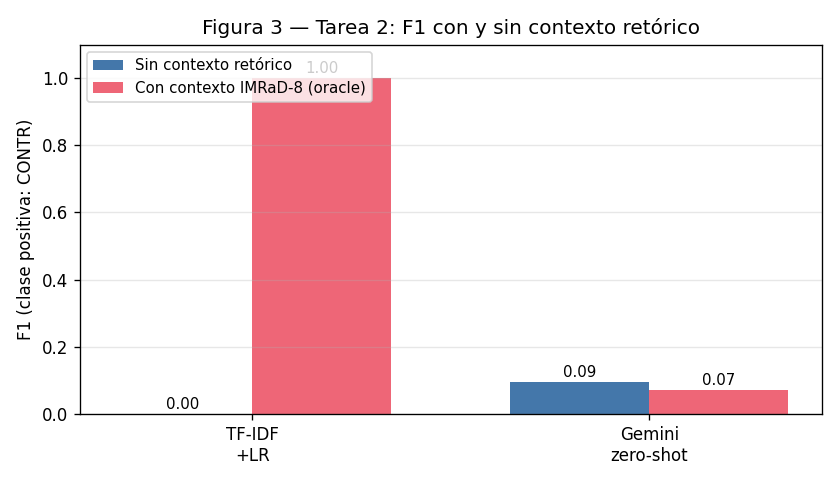

In [6]:
display(Image(filename=str(ROOT / 'reports' / 'entrega3' / 'tarea2_comparison.png')))

**Figura 3.** F1 de la clase positiva (CONTR) sin y con contexto retórico oracle. El TF-IDF refleja literalmente el oracle (la etiqueta es una de sus features). En Gemini, el contexto IMRaD-8 oracle no aporta señal positiva neta porque el modelo ya es muy permisivo en su definición de "contribución".

### C. Hallazgos

1. **La clase es severamente minoritaria.** Con sólo 5 positivos en test (base rate 3.03 %), métricas puntuales tienen alta varianza; los resultados se interpretan como evidencia direccional, no como cifras estables.
2. **TF-IDF sin contexto colapsa al 0.** Pese al `class_weight='balanced'`, el clasificador no predice ningún positivo en test. La señal léxica de CONTR es difícil de aislar sin información estructural.
3. **Gemini sin entrenamiento es muy permisivo.** Predice 80 positivos sobre 165 (recall 0.80, precision 0.05). Su definición de "contribución" en lenguaje natural no se alinea con el criterio del anotador.
4. **El upper bound del puente es alto, pero el puente realista no.** El TF-IDF + IMRaD-8 oracle alcanza F1 = 1.00 porque la feature *es* la etiqueta proxy; al mismo tiempo, Gemini con contexto oracle *no mejora* (de 0.094 a 0.071). Esto indica que el beneficio del puente Tarea 1→Tarea 2 está condicionado a (a) que el clasificador sepa explotar la feature retórica, y (b) que la etiqueta retórica sea precisa — lo cual a su vez está limitado por el F1 = 0.36 que la Tarea 1 obtiene en CONTR.
5. **El proxy CONTR a nivel de fragmento es insuficiente.** Para destrabar la Tarea 2 se requiere anotación dedicada de contribuciones (idealmente span-level), independiente de la etiqueta retórica.

### D. Limitaciones específicas de la Tarea 2

- **Etiqueta proxy:** se usó `etiqueta_anotador == 'CONTR'` en lugar de una anotación binaria dedicada de contribuciones, lo cual sub-representa contribuciones que aparecen embebidas en fragmentos etiquetados como RES o CONC.
- **Contexto oracle vs. predicho:** los resultados "con contexto" usan la etiqueta IMRaD-8 verdadera. Una evaluación realista debe usar la salida de Tarea 1 (limitada por F1 = 0.36 en CONTR), lo que reduciría aún más el beneficio del puente.
- **Sin clasificador supervisado neuronal:** no se evaluó SciBETO fine-tuneado en binario por restricciones de cómputo; se reserva para trabajo futuro junto con la anotación dedicada.

## IX. Estrategia de Despliegue

El modelo SciBETO-IMRaD, disponible en [HuggingFace Hub](https://huggingface.co/wiflore/SciBETO-IMRaD), se puede desplegar como servicio REST sobre una imagen Docker. La arquitectura mínima consta de tres componentes: (i) carga del modelo desde el Hub con tokenización Head+Tail 256+256 consistente con el entrenamiento; (ii) endpoint de inferencia que recibe un fragmento de texto y devuelve la etiqueta IMRaD y la probabilidad de confianza; y (iii) contenedor que garantiza reproducibilidad entre entornos CPU, GPU NVIDIA y Apple Silicon.

### A. Latencia

La latencia de inferencia depende del hardware: SciBETO-IMRaD en CPU de 8 núcleos alcanza ~150–200 ms/fragmento; en GPU T4 (AWS g4dn.xlarge), ~30–50 ms/fragmento. La alternativa Gemini 3-flash vía API introduce 800–1200 ms por llamada debido a la latencia de red, lo que la hace menos adecuada para procesamiento interactivo de alto volumen. Para el caso de uso académico (análisis de artículos individuales), la latencia en CPU es aceptable; para producción con carga concurrente, se requiere GPU o escalado horizontal.

### B. Costo por fragmento y punto de equilibrio

A precios públicos de mayo 2026, el costo unitario de las dos opciones principales es:

- **Gemini 3-flash API:** ~$0.00003/fragmento ($0.03 por 1,000 fragmentos). Sin costo de infraestructura fija, óptimo para volúmenes bajos.
- **SciBETO en EC2 Spot g4dn.xlarge** (~$0.16/h, throughput ~72,000 fragmentos/h): ~$0.0000022/fragmento. ~14× más barato que Gemini a escala.

El **punto de equilibrio** se sitúa en ~3,000 llamadas mensuales: por debajo, Gemini es más económico; por encima, SciBETO auto-hospedado en Spot es superior en costo.

### C. Almacenamiento

Los pesos del modelo (1.3 GB, `model.safetensors`) están alojados en HuggingFace Hub sin costo de almacenamiento ni límite de descargas. El dataset de entrenamiento ocupa ~50 MB; los resultados de inferencia por lote de 1,000 fragmentos representan menos de 1 MB en JSON.

### D. Recomendación

Para la demo académica: **HF Spaces (Gradio, free tier)** — acceso público inmediato sin infraestructura. Para procesamiento batch de nuevos artículos a escala: **EC2 Spot g4dn.xlarge** (~$0.16/h), con la imagen Docker disponible en la rama `deployment` del repositorio.

## X. Conclusiones y Trabajo Futuro

Los experimentos de la **Tarea 1** demuestran que **ninguna familia de modelos domina en todas las dimensiones relevantes**. SciBETO fine-tuneado ofrece F1-macro 4c = 0.7083 con reproducibilidad total y sin dependencias externas, siendo la opción de producción más segura a alto volumen. Gemini con definiciones discriminativas en zero-shot logra el mayor F1-macro 8c (0.6098) con tiempo de despliegue mínimo y ventaja económica en servicios de bajo volumen. Qwen3-8B con definiciones discriminativas establece un baseline LLM open-weight (F1-macro 8c = 0.4651) que supera al baseline TF-IDF sin entrenamiento supervisado, abriendo la vía al fine-tuning LoRA como contribución inmediata pendiente.

El hallazgo metodológico central de la Tarea 1 es que **para clasificación retórica de grano fino, la precisión semántica de las definiciones de clase es más determinante que la provisión de ejemplos en el prompt**: redefinir BACK y RES con criterios observables generó +10.9 pp en Gemini, mientras que agregar 8 ejemplos del dominio redujo el F1-macro 8c en −14 pp. Este efecto fue corroborado de forma independiente en hardware NVIDIA con Qwen3-8B (−6.3 pp).

Los experimentos preliminares de la **Tarea 2** confirman su mayor dificultad (base rate 3 %): TF-IDF sin contexto colapsa al F1 = 0, Gemini zero-shot es excesivamente permisivo (precision 0.05) y el puente con etiqueta retórica oracle no produce beneficio neto en LLMs. La conclusión operativa es que **la Tarea 2 requiere una anotación dedicada de contribuciones (idealmente span-level) antes de poder cuantificar realísticamente el beneficio del puente Tarea 1 → Tarea 2**.

**Trabajo futuro:**
1. Anotación dedicada de contribuciones a nivel de span sobre el subconjunto de test, complementaria al esquema IMRaD-8.
2. Fine-tuning LoRA de Qwen3-8B sobre las 1,264 instancias de entrenamiento, con el objetivo de alcanzar el rango de SciBETO/Gemini conservando las ventajas de un modelo open-weight.
3. Evaluación realista del puente Tarea 1 → Tarea 2 usando la etiqueta IMRaD-8 *predicha* (no oracle) como rasgo de entrada al clasificador binario.
4. Ampliación del corpus anotado en clases minoritarias (CONTR, LIM) para reducir el cuello de botella estadístico identificado.
5. Despliegue del demostrador (ver Sección IX).

---
**Recursos de Reproducibilidad:**
- Código: https://github.com/wiflore/Pry-ScienceDocsSpanish
- Checkpoint SciBETO-IMRaD: https://huggingface.co/wiflore/SciBETO-IMRaD *(reemplazar `wiflore`)*


## Referencias

[1] Grupo FLAG–TICsW, "Análisis de documentos científicos en español," Propuesta de Proyecto de Grado, Departamento de Ingeniería de Sistemas y Computación, Universidad de los Andes, 2026.

[2] S. Teufel and M. Moens, "Discourse-level argumentation in scientific articles: Human and automatic annotation," in *Towards Standards and Tools for Discourse Tagging*, 1999.

[3] M. Liakata, S. Teufel, A. Siddharthan, and C. Batchelor, "Corpora for the conceptualisation and zoning of scientific papers," in *Proc. 7th Int. Conf. Language Resources and Evaluation (LREC'10)*, 2010.

[4] H. Kataria and A. Gupta, "NLP-Titan at SemEval-2023 Task 6: Identification of rhetorical roles using sequential sentence classification," in *Proc. 17th Int. Workshop on Semantic Evaluation (SemEval-2023)*, 2023, pp. 1365–1370. doi: 10.18653/v1/2023.semeval-1.189.

[5] J. D'Souza, S. Auer, and T. Pedersen, "SemEval-2021 Task 11: NLPContributionGraph — Structuring scholarly NLP contributions for a research knowledge graph," in *Proc. 15th Int. Workshop on Semantic Evaluation (SemEval-2021)*, 2021, pp. 364–376. doi: 10.18653/v1/2021.semeval-1.44.